# Road Follower - Train Model

In this notebook we will train a neural network to take an input image, and output a set of x, y values corresponding to a target.

We will be using PyTorch deep learning framework to train ResNet18 neural network architecture model for road follower application.

In [1]:
import torch
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.datasets as datasets
import torchvision.models as models
import torchvision.transforms as transforms
import glob
import PIL.Image
import os
import numpy as np
import pandas as pd

DATASET_NAME = 'dataset_labeled_2'
DATASET_DIR = 'datasets/' + DATASET_NAME

### Create Dataset Instance

Here we create a custom ``torch.utils.data.Dataset`` implementation, which implements the ``__len__`` and ``__getitem__`` functions.  This class
is responsible for loading images and parsing the x, y values from the image filenames.  Because we implement the ``torch.utils.data.Dataset`` class,
we can use all of the torch data utilities :)

We hard coded some transformations (like color jitter) into our dataset.  We made random horizontal flips optional (in case you want to follow a non-symmetric path, like a road
where we need to 'stay right').  If it doesn't matter whether your robot follows some convention, you could enable flips to augment the dataset.

In [2]:
_label_cache = {}
def _load_labels(csv_file):
    if csv_file not in _label_cache:
        df = pd.read_csv(csv_file)
        _label_cache[csv_file] = {os.path.basename(r['image_path']): (r['x_norm'], r['y_norm']) for _, r in df.iterrows()}
    return _label_cache[csv_file]

def get_x(path, width, csv_file=f'{DATASET_DIR}/labels.csv'):
    return _load_labels(csv_file)[os.path.basename(path)][0]

def get_y(path, height, csv_file=f'{DATASET_DIR}/labels.csv'):
    return _load_labels(csv_file)[os.path.basename(path)][1]


class XYDataset(torch.utils.data.Dataset):
    
    def __init__(self, directory, random_hflips=False):
        self.directory = directory
        self.random_hflips = random_hflips
        self.image_paths = glob.glob(os.path.join(self.directory, '*.jpg'))
        self.color_jitter = transforms.ColorJitter(0.3, 0.3, 0.3, 0.3)
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image_path = self.image_paths[idx]

        image = PIL.Image.open(image_path)
        width, height = image.size
        x = float(get_x(os.path.basename(image_path), width))
        y = float(get_y(os.path.basename(image_path), height))
        
        if self.random_hflips and float(np.random.rand(1)) > 0.5:
            image = transforms.functional.hflip(image)
            x = 1 - x
        
        image = self.color_jitter(image)
        image = transforms.functional.resize(image, (224, 224))
        image = transforms.functional.to_tensor(image)
        image = image.numpy()[::-1].copy()
        image = torch.from_numpy(image)
        image = transforms.functional.normalize(image, [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        
        return image, torch.tensor([x, y]).float()

dataset = XYDataset(DATASET_DIR, random_hflips=True)

# Training

In [3]:
train_p, val_p, test_p = 0.8, 0.1, 0.1
num_train = int(train_p * len(dataset))
num_val = int(val_p * len(dataset))
num_test = len(dataset) - num_train - num_val
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(dataset, [num_train, num_val, num_test])

In [4]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0
)

In [5]:
model = models.resnet18(pretrained=True)

In [6]:
model.fc = torch.nn.Linear(512, 2)
device = torch.device('cuda')
model = model.to(device)
print(device)

cuda


In [7]:
NUM_EPOCHS = 70
os.makedirs(f'models/{DATASET_NAME}', exist_ok=True)
BEST_MODEL_PATH = f'models/{DATASET_NAME}/best_steering_model_xy.pth'
best_loss = 1e9
optimizer = optim.Adam(model.parameters())

for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss = 0.0
    train_mae = 0.0
    for images, labels in iter(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = F.mse_loss(outputs, labels)
        train_loss += float(loss)
        train_mae += float(F.l1_loss(outputs, labels))
        loss.backward()
        optimizer.step()
    train_loss /= len(train_loader)
    train_mae /= len(train_loader)

    model.eval()
    val_loss = 0.0
    val_mae = 0.0
    val_euclidean = 0.0
    with torch.no_grad():
        for images, labels in iter(val_loader):
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            val_loss += float(F.mse_loss(outputs, labels))
            val_mae += float(F.l1_loss(outputs, labels))
            # Euclidean distance between predicted and true (x, y)
            val_euclidean += float(torch.mean(torch.sqrt(torch.sum((outputs - labels) ** 2, dim=1))))
    val_loss /= len(val_loader)
    val_mae /= len(val_loader)
    val_euclidean /= len(val_loader)

    print('Epoch %d/%d — Train Loss: %.4f, Train MAE: %.4f | Val Loss: %.4f, Val MAE: %.4f, Val Dist: %.4f'
          % (epoch + 1, NUM_EPOCHS, train_loss, train_mae, val_loss, val_mae, val_euclidean))

    if val_loss < best_loss:
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        best_loss = val_loss

Epoch 1/70 — Train Loss: 0.3828, Train MAE: 0.3980 | Val Loss: 0.0613, Val MAE: 0.1984, Val Dist: 0.3133
Epoch 2/70 — Train Loss: 0.0256, Train MAE: 0.1258 | Val Loss: 0.0141, Val MAE: 0.0992, Val Dist: 0.1502
Epoch 3/70 — Train Loss: 0.0175, Train MAE: 0.1068 | Val Loss: 0.0154, Val MAE: 0.0980, Val Dist: 0.1586
Epoch 4/70 — Train Loss: 0.0128, Train MAE: 0.0875 | Val Loss: 0.0143, Val MAE: 0.0945, Val Dist: 0.1480
Epoch 5/70 — Train Loss: 0.0114, Train MAE: 0.0836 | Val Loss: 0.0104, Val MAE: 0.0799, Val Dist: 0.1267
Epoch 6/70 — Train Loss: 0.0182, Train MAE: 0.1050 | Val Loss: 0.0054, Val MAE: 0.0585, Val Dist: 0.0909
Epoch 7/70 — Train Loss: 0.0160, Train MAE: 0.0978 | Val Loss: 0.0118, Val MAE: 0.0866, Val Dist: 0.1348
Epoch 8/70 — Train Loss: 0.0101, Train MAE: 0.0790 | Val Loss: 0.0131, Val MAE: 0.0928, Val Dist: 0.1518
Epoch 9/70 — Train Loss: 0.0114, Train MAE: 0.0866 | Val Loss: 0.0049, Val MAE: 0.0517, Val Dist: 0.0792
Epoch 10/70 — Train Loss: 0.0122, Train MAE: 0.0871 | V

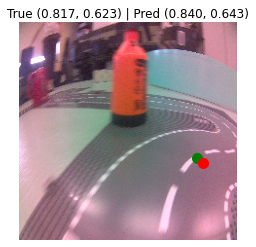

True x: 0.817, True y: 0.623
Pred x: 0.840, Pred y: 0.643


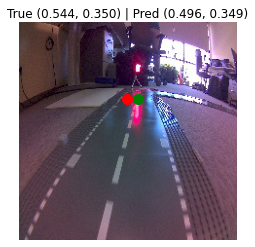

True x: 0.544, True y: 0.350
Pred x: 0.496, Pred y: 0.349


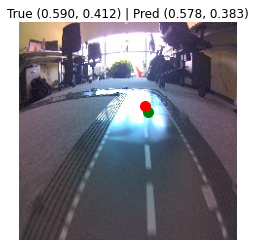

True x: 0.590, True y: 0.412
Pred x: 0.578, Pred y: 0.383


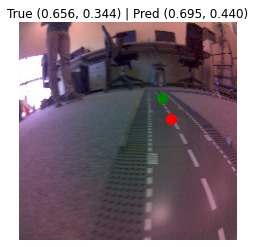

True x: 0.656, True y: 0.344
Pred x: 0.695, Pred y: 0.440


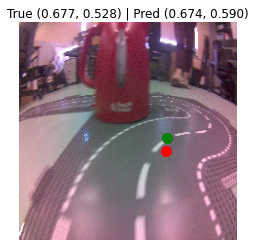

True x: 0.677, True y: 0.528
Pred x: 0.674, Pred y: 0.590


In [8]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import torch
import PIL.Image
import os
import torchvision.transforms as transforms

def get_image_tensor(image_path):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),   # ResNet expects 224x224
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],   # ImageNet mean
                             [0.229, 0.224, 0.225])    # ImageNet std
    ])
    image = PIL.Image.open(image_path).convert('RGB')
    return transform(image)

model = models.resnet18(pretrained=False)
model.fc = torch.nn.Linear(512, 2)
state_dict = torch.load(BEST_MODEL_PATH, map_location='cpu')
model.load_state_dict(state_dict)
model.eval()

samples = [dataset.image_paths[i] for i in test_loader.dataset.indices]
random.shuffle(samples)

for s in samples[:5]:
    image = PIL.Image.open(s)
    width, height = image.size
    
    true_x = get_x(os.path.basename(s), width)
    true_y = get_y(os.path.basename(s), height)
    
    with torch.no_grad():
        output = model(get_image_tensor(s).unsqueeze(0))[0].numpy()
    
    pred_x, pred_y = output[0], output[1]
    
    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.title(f"True ({true_x:.3f}, {true_y:.3f}) | Pred ({pred_x:.3f}, {pred_y:.3f})")
    plt.scatter(true_x * width, true_y * height, color='green', label='True', s=100)
    plt.scatter(pred_x * width, pred_y * height, color='red', label='Pred', s=100)
    plt.axis('off')
    plt.show()
    
    print(f"True x: {true_x:.3f}, True y: {true_y:.3f}")
    print(f"Pred x: {pred_x:.3f}, Pred y: {pred_y:.3f}")

Once the model is trained, it will generate ``best_steering_model_xy.pth`` file which you can use for inferencing in the live demo notebook.

If you trained on a different machine other than JetBot, you'll need to upload this to the JetBot to the ``road_following`` example folder.

In [9]:
import torch
state_dict = torch.load(BEST_MODEL_PATH, map_location='cpu')
torch.save(state_dict, f'models/{DATASET_NAME}/model_to_import.pth', _use_new_zipfile_serialization=False)